This file contains the data extraction / preparation pipeline for the project.

*   Raw, daily OHLCV (Open, High, Low, Close, Volume) data is extracted from the Alpaca API.
*   Includes **30** major large-cap **US NASDAQ** stocks (such as AAPL, MSFT, GOOGL, NVDA, TSLA) over the past **4** years and the Nasdaq-100 ETF (QQQ) as a macro index.
*   For each stock, I added 14 technical indicators and 6 time-based features. These include:
    1. **Technical:** SMA (5&20), EMA (5&20), MACD (fast:12, slow:26, period:9),RSI(14), ATR (14).
    2. **Time:** Sinusoidal encodings for Day of Week, Day of Month, and Month of Year
*   Saved into a SQLite DB, **financial_data.db**.














In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%pip install alpaca-py mplfinance numpy pandas
%pip install mplfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.5/122.5 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 8.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import sqlite3
from datetime import datetime
import matplotlib.pyplot as plt
import mplfinance as mpf

from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame


pd.options.mode.chained_assignment = None # default='warn'

In [ ]:
def inspect_data(df, n=5):
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())
    if isinstance(df.index, pd.MultiIndex):
        print("Index names:", df.index.names)
    else:
        print("Index name:", df.index.name)
    print("\nHead:\n", df.head(n))
    print("\nTail:\n", df.tail(n))

def check_missing(df):
    return df.isnull().sum()

def convert_timestamp(df, level_name='timestamp', tz="UTC", fmt="%Y-%m-%d"):
    df_copy = df.copy()
    if isinstance(df_copy.index, pd.MultiIndex):
        timestamps = df_copy.index.get_level_values(level_name)
        df_copy.index = df_copy.index.set_levels(
            [df_copy.index.levels[0], pd.to_datetime(timestamps).tz_convert(tz).strftime(fmt)],
            level=level_name
        )
    else:
         df_copy.index = pd.to_datetime(df_copy.index).tz_convert(tz).strftime(fmt)
         df_copy.index.name = level_name # Ensure index has a name
    return df_copy

def add_dayofweek(df, index_level='timestamp'):
    """
    Adds cyclical day-of-week features.

    """
    df_copy = df.copy()
    if isinstance(df_copy.index, pd.MultiIndex):
      idx = pd.to_datetime(df_copy.index.get_level_values(index_level))
    else:
      idx = pd.to_datetime(df_copy.index)

    dow = idx.dayofweek
    df_copy["dow_cos"] = np.cos(2 * np.pi * dow / 7)
    df_copy["dow_sin"] = np.sin(2 * np.pi * dow / 7)
    return df_copy

def add_dayofmonth(df, index_level='timestamp'):
    df_copy = df.copy()
    if isinstance(df_copy.index, pd.MultiIndex):
      idx = pd.to_datetime(df_copy.index.get_level_values(index_level))
    else:
      idx = pd.to_datetime(df_copy.index)

    day = idx.day
    days_in_month = idx.days_in_month 
    df_copy["dom_cos"] = np.cos(2 * np.pi * day / days_in_month)
    df_copy["dom_sin"] = np.sin(2 * np.pi * day / days_in_month)
    return df_copy

def add_monthofyear(df, index_level='timestamp'):
    df_copy = df.copy()
    if isinstance(df_copy.index, pd.MultiIndex):
      idx = pd.to_datetime(df_copy.index.get_level_values(index_level))
    else:
      idx = pd.to_datetime(df_copy.index)

    month = idx.month
    df_copy["moy_cos"] = np.cos(2 * np.pi * month / 12)
    df_copy["moy_sin"] = np.sin(2 * np.pi * month / 12)
    return df_copy

def plot_price(df, title="Close Price"):
    """Plots the close price.

    """
    df["close"].plot(title=title, figsize=(12, 6))
    plt.show()


def add_moving_averages(df, windows=[5, 20]):
    """
    Adds SMA and EMA.

    """
    df_copy = df.copy()
    for w in windows:
        df_copy[f'sma_{w}'] = df_copy['close'].rolling(window=w).mean()
        df_copy[f'ema_{w}'] = df_copy['close'].ewm(span=w, adjust=False).mean()
    return df_copy

def add_macd(df, fast_period=12, slow_period=26, signal_period=9):
    """
    Adds MACDs.

    """
    df_copy = df.copy()
    ema_fast = df_copy['close'].ewm(span=fast_period, adjust=False).mean()
    ema_slow = df_copy['close'].ewm(span=slow_period, adjust=False).mean()
    df_copy['macd'] = ema_fast - ema_slow
    df_copy['macd_signal'] = df_copy['macd'].ewm(span=signal_period, adjust=False).mean()
    df_copy['macd_hist'] = df_copy['macd'] - df_copy['macd_signal']
    return df_copy

def add_rsi(df, window=14):
    """
    Adds RSI.

    """
    df_copy = df.copy()
    delta = df_copy['close'].diff()
    gain = delta.where(delta > 0, 0).fillna(0)
    loss = -delta.where(delta < 0, 0).fillna(0)
    avg_gain = gain.ewm(com=window - 1, adjust=False).mean()
    avg_loss = loss.ewm(com=window - 1, adjust=False).mean()
    rs = avg_gain / (avg_loss + 1e-8) # Avoid division by zero
    df_copy[f'rsi_{window}'] = 100 - (100 / (1 + rs))
    return df_copy

def add_atr(df, window=14):
    """
    Adds ATR.

    """
    df_copy = df.copy()
    df_copy['close_shifted'] = df_copy['close'].shift(1)
    high_low = df_copy['high'] - df_copy['low']
    high_close = np.abs(df_copy['high'] - df_copy['close_shifted'])
    low_close = np.abs(df_copy['low'] - df_copy['close_shifted'])
    tr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1, skipna=False)
    df_copy[f'atr_{window}'] = tr.ewm(com=window - 1, adjust=False).mean()
    df_copy.drop(columns=['close_shifted'], inplace=True)
    return df_copy

def add_all_technical_indicators(df, ma_windows=[5, 20]):
    """Wrapper to add all technical indicators."""
    df_copy = df.copy()
    df_copy = add_moving_averages(df_copy, windows=ma_windows)
    df_copy = add_macd(df_copy)
    df_copy = add_rsi(df_copy)
    df_copy = add_atr(df_copy)
    return df_copy

In [ ]:
STOCK_SYMBOL = "QQQ" ############
START_DATE = datetime(2021, 7, 1)
END_DATE = datetime(2025, 10, 15)
DB_PATH = '/content/drive/MyDrive/financial_data.db'

# Alpaca API
API_KEY = "         "
API_SECRET = "            "

# Initialize Alpaca client
stock_client = StockHistoricalDataClient(API_KEY, API_SECRET)

# Create the request object
stock_req = StockBarsRequest(
    symbol_or_symbols=[STOCK_SYMBOL],
    timeframe=TimeFrame.Day,
    start=START_DATE,
    end=END_DATE,
    limit=10000,
    adjustment="all" # Use split/dividend adjusted data
)

# Fetch the data
stock_bars = stock_client.get_stock_bars(stock_req)

# Keep only the data for the specific symbol (Alpaca returns a MultiIndex)
raw_df = stock_bars.df.loc[STOCK_SYMBOL]

print(f"Fetched {raw_df.shape[0]} data points for {STOCK_SYMBOL}")

Fetched 1077 data points for QQQ


--- Inspecting Raw Data for QQQ ---
Shape: (1077, 7)
Columns: ['open', 'high', 'low', 'close', 'volume', 'trade_count', 'vwap']
Index name: timestamp

Head:
                              open    high     low   close      volume  \
timestamp                                                               
2021-07-01 04:00:00+00:00  344.29  345.28  342.94  344.77  29546803.0   
2021-07-02 04:00:00+00:00  346.67  349.05  346.44  348.73  33269522.0   
2021-07-06 04:00:00+00:00  349.33  350.52  346.64  350.24  39216822.0   
2021-07-07 04:00:00+00:00  352.44  352.74  349.02  350.98  36063831.0   
2021-07-08 04:00:00+00:00  345.91  349.71  344.63  348.86  51985698.0   

                           trade_count    vwap  
timestamp                                       
2021-07-01 04:00:00+00:00     203689.0  344.26  
2021-07-02 04:00:00+00:00     208727.0  347.73  
2021-07-06 04:00:00+00:00     270510.0  349.11  
2021-07-07 04:00:00+00:00     277169.0  350.86  
2021-07-08 04:00:00+00:00     403407

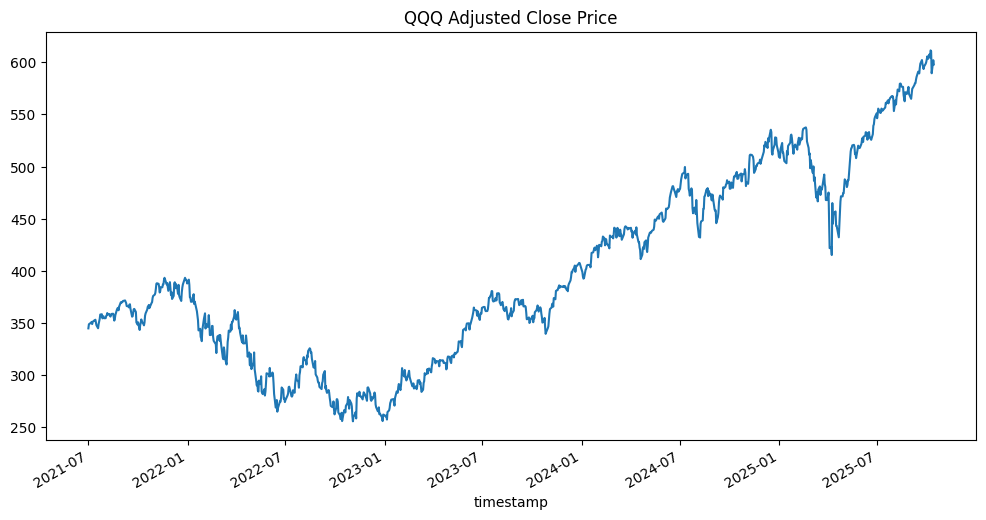

In [ ]:
print(f"--- Inspecting Raw Data for {STOCK_SYMBOL} ---")
inspect_data(raw_df)

print(f"\n--- Checking Missing Values for {STOCK_SYMBOL} ---")
print(check_missing(raw_df))

print(f"\n--- Plotting Close Price for {STOCK_SYMBOL} ---")
plot_price(raw_df, title=f"{STOCK_SYMBOL} Adjusted Close Price")

In [ ]:
print("Adding Features")

processed_df = convert_timestamp(raw_df, level_name='timestamp') # Use the single index name

processed_df = add_all_technical_indicators(processed_df)

processed_df = add_dayofweek(processed_df, index_level='timestamp')
processed_df = add_dayofmonth(processed_df, index_level='timestamp')
processed_df = add_monthofyear(processed_df, index_level='timestamp')

original_rows = processed_df.shape[0]
processed_df.dropna(inplace=True)
print(f"Dropped {original_rows - processed_df.shape[0]} rows containing NaNs from indicator calculation.")

print("\n--- Inspecting Data After Feature Engineering ---")
inspect_data(processed_df)

--- Adding Features ---
Dropped 19 rows containing NaNs from indicator calculation.

--- Inspecting Data After Feature Engineering ---
Shape: (1058, 22)
Columns: ['open', 'high', 'low', 'close', 'volume', 'trade_count', 'vwap', 'sma_5', 'ema_5', 'sma_20', 'ema_20', 'macd', 'macd_signal', 'macd_hist', 'rsi_14', 'atr_14', 'dow_cos', 'dow_sin', 'dom_cos', 'dom_sin', 'moy_cos', 'moy_sin']
Index name: timestamp

Head:
               open    high     low   close      volume  trade_count    vwap  \
timestamp                                                                     
2021-07-29  355.16  357.52  355.16  356.35  25885621.0     184798.0  356.75   
2021-07-30  352.43  355.08  352.40  354.50  36847229.0     253973.0  354.11   
2021-08-02  356.17  356.74  353.82  354.53  27716332.0     207515.0  355.29   
2021-08-03  355.19  356.79  352.00  356.68  35915519.0     264005.0  354.80   
2021-08-04  356.64  358.14  355.53  357.19  29882010.0     228029.0  356.89   

              sma_5       em

In [ ]:
print(f"--- Storing Processed Data for {STOCK_SYMBOL} in SQLite ---")

conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

table_name = STOCK_SYMBOL

processed_df.to_sql(table_name, conn, if_exists='replace', index=True, index_label='timestamp')

print(f"DataFrame successfully written to table '{table_name}' in '{DB_PATH}'")
conn.close()

--- Storing Processed Data for QQQ in SQLite ---
DataFrame successfully written to table 'QQQ' in '/content/drive/MyDrive/financial_data.db'


In [ ]:
# SQLite Inspection Utilities
def list_tables(db_path):
    """Lists all tables in the SQLite database."""
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
    tables = [table[0] for table in cursor.fetchall()]
    conn.close()
    print("Tables in database:", tables)
    return tables

def inspect_table(db_path, table_name, n=5):
    """Fetches and displays the first n rows of a table."""
    conn = sqlite3.connect(db_path)
    print(f"\n--- First {n} rows of table '{table_name}' ---")
    try:
        df = pd.read_sql(f"SELECT * FROM {table_name} LIMIT {n}", conn, index_col='timestamp')
        print(df)
    except Exception as e:
        print(f"Error reading table {table_name}: {e}")
    conn.close()

def get_table_schema(db_path, table_name):
    """Gets the schema (column names and types) of a table."""
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    print(f"\n--- Schema of table '{table_name}' ---")
    try:
        cursor.execute(f"PRAGMA table_info({table_name});")
        schema = cursor.fetchall()
        print("Column Name | Data Type | Not Null | Default Value | Primary Key")
        print("-" * 70)
        for col in schema:
            print(f"{col[1]:<12} | {col[2]:<10} | {col[3]:<8} | {str(col[4]):<13} | {col[5]}")
    except Exception as e:
        print(f"Error getting schema for table {table_name}: {e}")
    conn.close()

In [ ]:
# Inspect the database
tables = list_tables(DB_PATH)

if STOCK_SYMBOL in tables:
    inspect_table(DB_PATH, STOCK_SYMBOL)
    get_table_schema(DB_PATH, STOCK_SYMBOL)
else:
    print(f"Table {STOCK_SYMBOL} not found in the database.")

Tables in database: ['AAPL', 'MSFT', 'NVDA', 'AMZN', 'GOOGL', 'META', 'TSLA', 'AVGO', 'COST', 'NFLX', 'AMD', 'ADBE', 'INTC', 'CSCO', 'TMUS', 'QCOM', 'CMCSA', 'MU', 'INTU', 'AMAT', 'GILD', 'ASML', 'LRCX', 'PANW', 'VRTX', 'REGN', 'CRWD', 'AMGN', 'SBUX', 'PEP', 'QQQ']

--- First 5 rows of table 'QQQ' ---
              open    high     low   close      volume  trade_count    vwap  \
timestamp                                                                     
2021-07-29  355.16  357.52  355.16  356.35  25885621.0     184798.0  356.75   
2021-07-30  352.43  355.08  352.40  354.50  36847229.0     253973.0  354.11   
2021-08-02  356.17  356.74  353.82  354.53  27716332.0     207515.0  355.29   
2021-08-03  355.19  356.79  352.00  356.68  35915519.0     264005.0  354.80   
2021-08-04  356.64  358.14  355.53  357.19  29882010.0     228029.0  356.89   

              sma_5       ema_5    sma_20  ...  macd_signal  macd_hist  \
timestamp                                  ...                       